# Error mitigation

Perceval offers natively some mitigation techniques, that try to get the noisy results closer to the expected noiseless results by applying some corrections. They rely on extra measurements with different parameters than the original experiment. Some of them will create several sub-jobs and combine them to get better approximations of the results.

There exist algorithms for different purposes:
- HOM and g2 mitigation
- Loss mitigation
- Compilation/phase error averaging
- Detector balancing

It is worth noting that, in a noiseless environment (such as noiseless simulators), these techniques should not be used, as they will slow down the whole process without bringing better results. Also, some techniques are not compatible with non-unitary Experiments, including feed-forwarded Experiments, or have some restrictions on parameters (for example, the loss mitigation can't be used if there are less than 3 requested photons).

In [8]:
from perceval import Experiment, BS, FockState, pdisplay, SimulatedComputer, Execution, Computation, NoiseModel, \
    RemoteComputer

## Basic example

We will take a simple HOM experiment, and show that our mitigation techniques manage to get closer to the perfect distribution.

As a reminder, for an HOM experiment, we take a single beam splitter and inject 1 photon into each mode |1,1>. We then expect to see 50% of |2, 0> and 50% of |0, 2>.

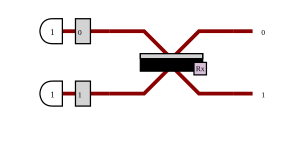

In [10]:
# Start as usual by defining your Experiment

e = Experiment(2)
e.add(0, BS())
e.with_input(FockState([1, 1]))
e.min_detected_photons_filter(2)

pdisplay(e)

In [11]:
# Then define a Computer

comp = SimulatedComputer("SLOS")

# As a reminder, we can compute for the perfect case like this
# TODO: use a Sampler equivalent and make an Execution in one line
# exec = Sampler(comp, e).probs

computation = Computation(comp.get_command("probs"), e)
exec = Execution(computation, comp)

print(exec())

{'results': {
	|2,0>: 0.5
	|0,2>: 0.5
}, 'global_perf': 1.0000000000000004}


Now, we are going to add some noise, and investigate how different mitigation techniques can be combined to get better results.

In [13]:
comp.noise = NoiseModel(indistinguishability=0.8, g2=0.03)
# TODO: add detector imbalance

# That's all, we can now do as before
# TODO: use a Sampler equivalent and make an Execution in one line
# exec = Sampler(comp, e).probs
computation = Computation(comp.get_command("probs"), e)
exec = Execution(computation, comp)

print(exec()['results'])

{
	|4,0>: 2.6915308042819604e-05
	|2,2>: 6.579297521578127e-05
	|3,1>: 5.9811795650710234e-05
	|0,4>: 2.6915308042819604e-05
	|1,3>: 5.9811795650710234e-05
	|3,0>: 0.006852766518841966
	|1,2>: 0.00837560352302907
	|2,1>: 0.00837560352302907
	|0,3>: 0.006852766518841966
	|2,0>: 0.4361868057301448
	|0,2>: 0.4361868057301448
	|1,1>: 0.09693040127336552
}


We can see that many unwanted states appeared, and we only get a desired state 87.2% of the time. # TODO

The mitigations are defined at the Computer level, so that they can go along the noise. The easiest way to add mitigation techniques is to use the MitigationFactory, but we'll see later how to add custom mitigations.

In [ ]:
comp.mitigations = MitigationFactory.build(level=1, experiment=e)  # The highest the level, the more mitigations are applied, but the more expensive they become

# That's all, we can now do as before
# TODO: use a Sampler equivalent and make an Execution in one line
# exec = Sampler(comp, e).probs

computation = Computation(comp.get_command("probs"), e)
exec = Execution(computation, comp)

print(exec())

We can see that the mitigation techniques improved the results # TODO

## Advanced example

In our example, we only set HOM, g2 and detector imbalance errors. Let's investigate on how we can combine the mitigations for these kind of errors by choosing them by hand.

In [ ]:
# As a starting point, we will use detector balancing only
comp.mitigations = [DetectorBalancing()]


# TODO: use a Sampler equivalent and make an Execution in one line
# exec = Sampler(comp, e).probs

computation = Computation(comp.get_command("probs"), e)
exec = Execution(computation, comp)

print(exec()["results"])

In [ ]:
# Now, we use HOM and g2 mitigations only

# Order is the number of photons that we will remove on sub-jobs.
# The higher the order, the better the results, but the number of sub-jobs increases exponentially # TODO: this is not exponential
comp.mitigations = [PhotonMitigation(order=1)]


# TODO: use a Sampler equivalent and make an Execution in one line
# exec = Sampler(comp, e).probs

computation = Computation(comp.get_command("probs"), e)
exec = Execution(computation, comp)

print(exec()["results"])

In [ ]:
# Finally, we can use both at the same time.
# Mitigations are applied left to right, meaning that each sub-job generated by a mitigation is fed to the next mitigation of the list. As such, it is advised not to repeat a given mitigation technique, and to use the same order as provided by the MitigationFactory

comp.mitigations = [PhotonMitigation(order=1), DetectorBalancing()]

# TODO: use a Sampler equivalent and make an Execution in one line
# exec = Sampler(comp, e).probs

computation = Computation(comp.get_command("probs"), e)
exec = Execution(computation, comp)

print(exec()["results"])

In [ ]:
# To emphasize the difference, we also do a mitigation in the opposite order

# We can also change the noise or the mitigations for a limited scope
with comp.apply_configuration(mitigations=[DetectorBalancing(), PhotonMitigation(order=1)]):
    # TODO: use a Sampler equivalent and make an Execution in one line
    # exec = Sampler(comp, e).probs

    computation = Computation(comp.get_command("probs"), e)
    exec = Execution(computation, comp)

    print(exec()["results"])

We can see that the mitigations improved the results overall

## Remote Mitigation

When using RemoteComputer, a few things can change with error mitigation.

First, some QPUs may have a default mitigation, which is applied if nothing is specified. If a mitigation is manually given, it replaces the default mitigation.

Then, the mitigated Execution is sent to the cloud as a single job, and everything happens remotely. If needed (for example if the target platform doesn't support mitigations), this can be changed

In [ ]:
# comp = RemoteComputer(...)
#
# print(comp.specs.default_mitigations)  # TODO
#
# # Here, the mitigation would be sent with a single cloud job
# Sampler(comp, e).probs()
#
# # We can change this behaviour and apply the mitigations locally.
# # In this case, several jobs may be sent to the cloud and the postprocessing happens locally
# comp.use_mitigations_remotely = False
# Sampler(comp, e).probs()

It is also worth mentioning that the number of samples received at the end of a mitigated job may not correspond to the actual number of samples. Also, the number of shots is split between all sub-jobs, so the total number of shots will never exceed the requested number of shots.